In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import joblib

Load the dataset

In [72]:
df = pd.read_csv(r"D:\github\customer churn prediction\data\telco_churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Clean missing values

In [73]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [74]:
df.drop('customerID', axis=1, inplace=True)

Encode categorical variables

In [75]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [76]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


Train/test split

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [78]:
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Train a model - Logistic Regression Pipeline

In [79]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

Random Forest Pipeline (NO scaler)

In [85]:
from sklearn.ensemble import RandomForestClassifier

rf_imbalanced = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_imbalanced.fit(X_train, y_train)

Pipeline(steps=[('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [86]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Logistic Regression
y_pred_lr = lr_pipeline.predict(X_test)

# Random Forest
y_pred_rf = rf_imbalanced.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Logistic Regression
Accuracy: 0.8069552874378992
F1 Score: 0.6091954022988506
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Random Forest
Accuracy: 0.7899219304471257
F1 Score: 0.5555555555555556
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



Key Insight:

Your dataset is imbalanced:

Non-churn (0): 1035

Churn (1): 374

Recall & F1-score for class 1 (churn) matter more than accuracy.

Conclusion:

Logistic Regression outperforms Random Forest in identifying churn customers.

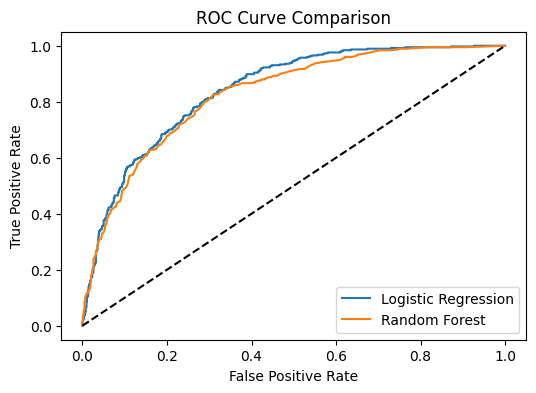

Logistic Regression ROC-AUC: 0.8415846443979436
Random Forest ROC-AUC: 0.826492546952905


In [90]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predicted probabilities
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_prob_rf = rf_imbalanced.predict_proba(X_test)[:, 1]

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# AUC scores
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


In [82]:
rf_balanced = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_balanced.fit(X_train, y_train)



Pipeline(steps=[('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [83]:
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_custom = (y_prob_lr >= 0.4).astype(int)


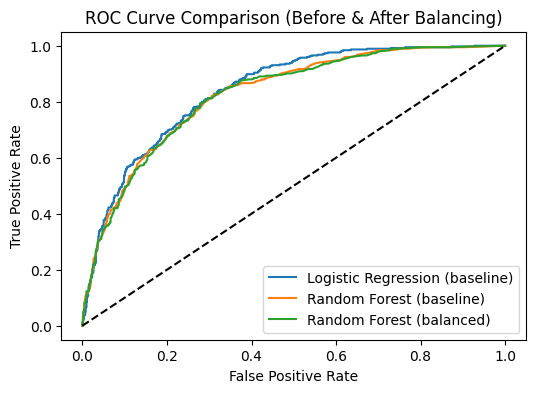

Balanced RF ROC-AUC: 0.8246208891988943


In [84]:
y_prob_rf_bal = rf_balanced.predict_proba(X_test)[:, 1]

fpr_rf_bal, tpr_rf_bal, _ = roc_curve(y_test, y_prob_rf_bal)

plt.figure(figsize=(6, 4))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression (baseline)")
plt.plot(fpr_rf, tpr_rf, label="Random Forest (baseline)")
plt.plot(fpr_rf_bal, tpr_rf_bal, label="Random Forest (balanced)")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Before & After Balancing)")
plt.legend()
plt.show()

print("Balanced RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf_bal))


In [87]:
y_pred_rf_imb = rf_imbalanced.predict(X_test)
y_pred_rf_bal = rf_balanced.predict(X_test)


In [88]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

comparison = pd.DataFrame({
    "Model": ["RF (Imbalanced)", "RF (Balanced)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf_imb),
        accuracy_score(y_test, y_pred_rf_bal)
    ],
    "Precision (Churn)": [
        precision_score(y_test, y_pred_rf_imb),
        precision_score(y_test, y_pred_rf_bal)
    ],
    "Recall (Churn)": [
        recall_score(y_test, y_pred_rf_imb),
        recall_score(y_test, y_pred_rf_bal)
    ],
    "F1-score (Churn)": [
        f1_score(y_test, y_pred_rf_imb),
        f1_score(y_test, y_pred_rf_bal)
    ]
})

comparison


,Model,Accuracy,Precision (Churn),Recall (Churn),F1-score (Churn)
0,RF (Imbalanced),0.789922,0.633562,0.494652,0.555556
1,RF (Balanced),0.789212,0.629630,0.500000,0.557377


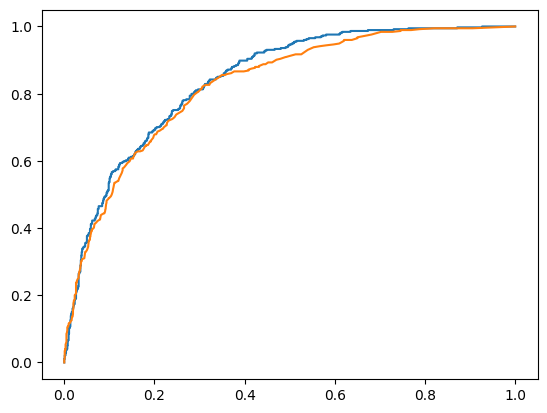

In [92]:
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression (baseline)")
plt.plot(fpr_rf, tpr_rf, label="Random Forest (baseline)")


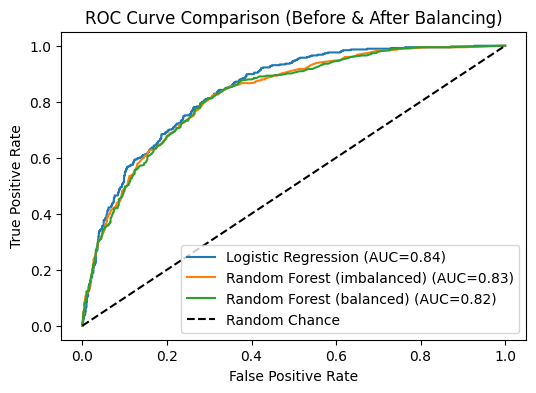

Logistic Regression ROC-AUC: 0.8415846443979436
Random Forest (imbalanced) ROC-AUC: 0.826492546952905
Random Forest (balanced) ROC-AUC: 0.8246208891988943


In [93]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predicted probabilities for all models
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]      # Logistic Regression
y_prob_rf = rf_imbalanced.predict_proba(X_test)[:, 1]    # Random Forest (imbalanced)
y_prob_rf_bal = rf_balanced.predict_proba(X_test)[:, 1]  # Random Forest (balanced)

# Compute ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_rf_bal, tpr_rf_bal, _ = roc_curve(y_test, y_prob_rf_bal)

# Plot all ROC curves
plt.figure(figsize=(6, 4))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (imbalanced) (AUC={roc_auc_score(y_test, y_prob_rf):.2f})")
plt.plot(fpr_rf_bal, tpr_rf_bal, label=f"Random Forest (balanced) (AUC={roc_auc_score(y_test, y_prob_rf_bal):.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Before & After Balancing)")
plt.legend()
plt.show()

# Print AUCs
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Random Forest (imbalanced) ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Random Forest (balanced) ROC-AUC:", roc_auc_score(y_test, y_prob_rf_bal))


From these numbers, we can see a clear story:

Logistic Regression (baseline): 0.842 → actually performs slightly better than the Random Forest models on your test set.

Random Forest (imbalanced): 0.826 → slightly lower, but still decent.

Random Forest (balanced): 0.825 → balancing didn’t really improve AUC; it’s basically the same as the imbalanced RF.